In [30]:
! pip install "numpy<2.0,>=1.20"
! pip install --upgrade shap scipy

  Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl.metadata (114 kB)
Using cached numpy-1.26.4-cp311-cp311-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
  Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-macosx_14_0_arm64.whl (5.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


In [31]:
! pip install shap

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', None)

## Load Data

In [34]:
# Load data
df_pan = pd.read_csv("./datasets/final_data/pan_final.csv")
df_sandal = pd.read_csv("./datasets/final_data/sandal_final.csv")
df_sunscreen = pd.read_csv("./datasets/final_data/sunscreen_final.csv")
df_wallet = pd.read_csv("./datasets/final_data/wallet_final.csv")

## Config

In [35]:
import numpy as np

CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "val_size": 0.2,
    "cv_folds": 5,

    "stage2_trials": 100,

    "target_cols": ["z_sold", "z_rating_credibility"],

    "metrics": ["rmse", "mae", "r2"]
}

## Data Split

In [36]:
from sklearn.model_selection import train_test_split

def split_data(df, config):
    train_val, test = train_test_split(
        df,
        test_size=config["test_size"],
        random_state=config["random_seed"]
    )

    train, val = train_test_split(
        train_val,
        test_size=config["val_size"],
        random_state=config["random_seed"]
    )

    return train, val, test

## Feature Type Detection

In [37]:
def detect_feature_types(df):
    numeric = []
    categorical = []
    binary = []

    for col in df.columns:

        # skip ID-like columns where it has many unique values as rows
        if df[col].dtype == "object" and df[col].nunique() > 0.9 * len(df):
            continue
        
        # detect binary features (usually contains 0 or 1)
        if df[col].nunique() == 2: 
            binary.append(col)

        # convert to numeric if possible
        elif pd.api.types.is_numeric_dtype(df[col]):
            numeric.append(col)

        else:
            categorical.append(col)

    return numeric, categorical, binary

def select_features(df):
    cols = df.columns.tolist()

    drop_cols = {
        "target",
        "title",
        "sold",
        "reviews",
        "gmv_cal",
        "rating",
        "rating_credibility",
        "z_sold",
        "z_rating_credibility",
        "id",
        "seller_name"
    }

    drop_log_related = {
        "log_sold",
        "log_reviews",
        "log_gmv_cal"
    }

    selected = []

    for c in cols:
        if c in drop_cols or c in drop_log_related:
            continue

        selected.append(c)

    return selected

## Feature Split (Between Log and Non-Log)

In [38]:
def split_features_by_model(df, num_cols):

    log_cols = [c for c in num_cols if c.startswith("log_")]

    raw_cols = []
    for c in log_cols:
        raw = c.replace("log_", "")
        if raw in df.columns:
            raw_cols.append(raw)

    # numeric that are not log or raw pairs
    other_numeric = [
        c for c in num_cols
        if not c.startswith("log_") and c not in raw_cols
    ]

    return log_cols, raw_cols, other_numeric

## Target Engine (PCA + Bootstrap)

In [39]:
from sklearn.decomposition import PCA

def bootstrap_pca_weights(train, cols, n_boot=200):
    weights = []

    X = train[cols].values

    for _ in range(n_boot):
        # sample row of X
        idx = np.random.choice(len(X), len(X), replace=True)
        sample = X[idx]

        # fit PCA on sample
        pca = PCA(n_components=1)
        pca.fit(sample)

        w = pca.components_[0]

        # Align sign
        if w[0] < 0:
            w = -w

        weights.append(w)

    weights = np.array(weights)

    mean_w = weights.mean(axis=0)
    std_w = weights.std(axis=0)

    return mean_w, std_w


def create_target(df, weights, cols):
    return df[cols].values @ weights

## Preprocessing Pipelines

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate the columns for linear and tree models
# Convert categorical features to one-hot encoding for model that can't process categorical features directly
def build_linear_pipeline(df, num_cols, cat_cols):

    log_cols, _, other_numeric = split_features_by_model(df, num_cols)

    linear_num_cols = log_cols + other_numeric

    print("\n[DEBUG] Linear features:")
    print(linear_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, linear_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])


def build_tree_pipeline(df, num_cols, cat_cols):

    log_cols, raw_cols, other_numeric = split_features_by_model(df, num_cols)

    tree_num_cols = raw_cols + other_numeric

    print("\n[DEBUG] Tree features:")
    print(tree_num_cols[:10])

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", num_pipe, tree_num_cols),
        ("cat", cat_pipe, cat_cols)
    ])

## List of Models

In [41]:
! pip install xgboost lightgbm catboost

In [42]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor


def get_models():
    return {
        # Baselines (to see if there is any linear relationship, and to check if more complex models are needed)
        "linear_regression": LinearRegression(),
        "ridge": Ridge(),
        "lasso": Lasso(),
        "elastic_net": ElasticNet(),

        # Tree Models
        "random_forest": RandomForestRegressor(),
        "extra_trees": ExtraTreesRegressor(),

        # Boosting 
        "xgboost": xgb.XGBRegressor(tree_method="hist"),
        "lightgbm": lgb.LGBMRegressor(verbosity=-1),
        "catboost": CatBoostRegressor(verbose=0),
    }

## Evaluation Metrics

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred)
    }

## Stage 1 - Fast Screening

In [44]:
from sklearn.model_selection import cross_validate

def stage1_search(models, X, y, preprocessors, config):

    results = []

    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    for name, model in models.items():

        pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", model)
        ])

        scores = cross_validate(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring=scoring,
            return_train_score=False
        )

        results.append({
            "model": name,
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_sd": scores["test_rmse"].std(),
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_r2_mean": scores["test_r2"].mean()
        })

    # sort
    results_df = pd.DataFrame(results).sort_values("cv_rmse_mean")

    # select top models
    top_models = results_df.head(3).to_dict("records")

    return top_models, results_df

## Stage 2 - Optuna Tuning

In [45]:
! pip install optuna

In [46]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

def tune_model(model_name, X, y, preprocessor, config):

    def objective(trial):

        # Linear Models
        if model_name == "linear_regression":
            model = LinearRegression()

        elif model_name == "ridge":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True)
            }
            model = Ridge(**params)

        elif model_name == "lasso":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True)
            }
            model = Lasso(**params)

        elif model_name == "elastic_net":
            params = {
                "alpha": trial.suggest_float("alpha", 1e-4, 1.0, log=True),
                "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0)
            }
            model = ElasticNet(**params)

        # Tree Models
        elif model_name == "random_forest":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
                "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"])
            }
            model = RandomForestRegressor(**params)

        elif model_name == "extra_trees":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 100, 400),
                "max_depth": trial.suggest_int("max_depth", 5, 30),
                "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
                "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5)
            }
            model = ExtraTreesRegressor(**params)

        # Boosting Models
        elif model_name == "xgboost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "max_depth": trial.suggest_int("max_depth", 3, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.6, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
                "gamma": trial.suggest_float("gamma", 0, 5),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True)
            }
            model = xgb.XGBRegressor(tree_method="hist", **params)

        elif model_name == "lightgbm":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 200, 800),
                "num_leaves": trial.suggest_int("num_leaves", 20, 150),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
                "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 5, 50)
            }
            model = lgb.LGBMRegressor(**params, verbosity=-1)

        elif model_name == "catboost":
            params = {
                "iterations": trial.suggest_int("iterations", 200, 800),
                "depth": trial.suggest_int("depth", 4, 10),
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
                "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
                "border_count": trial.suggest_int("border_count", 32, 255)
            }
            model = CatBoostRegressor(**params, verbose=0)

        # SVR
        elif model_name == "svr":
            params = {
                "C": trial.suggest_float("C", 0.1, 100, log=True),
                "epsilon": trial.suggest_float("epsilon", 0.01, 1.0),
                "kernel": trial.suggest_categorical("kernel", ["rbf", "linear"]),
                "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])
            }
            model = SVR(**params)

        # KNN
        elif model_name == "knn":
            params = {
                "n_neighbors": trial.suggest_int("n_neighbors", 3, 20),
                "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
                "p": trial.suggest_int("p", 1, 2)
            }
            model = KNeighborsRegressor(**params)

        else:
            raise ValueError(f"No tuning defined for {model_name}")

        # PIPELINE
        pipe = Pipeline([
            ("prep", preprocessor),
            ("model", model)
        ])

        score = cross_val_score(
            pipe,
            X,
            y,
            cv=config["cv_folds"],
            scoring="neg_root_mean_squared_error"
        ).mean()

        return -score

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=config["stage2_trials"])

    return study.best_params

## Build Model

In [48]:
def build_model(name, params):

    if name == "linear_regression":
        return LinearRegression(**params)

    elif name == "ridge":
        return Ridge(**params)

    elif name == "lasso":
        return Lasso(**params)

    elif name == "elastic_net":
        return ElasticNet(**params)

    elif name == "random_forest":
        return RandomForestRegressor(**params)

    elif name == "extra_trees":
        return ExtraTreesRegressor(**params)

    elif name == "xgboost":
        return xgb.XGBRegressor(tree_method="hist", **params)

    elif name == "lightgbm":
        return lgb.LGBMRegressor(**params, verbosity=-1)

    elif name == "catboost":
        return CatBoostRegressor(**params, verbose=0)

    else:
        raise ValueError(f"Unknown model: {name}")

## Final Training

In [49]:
def train_final(model, preprocessor, X_train, y_train):
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    return pipe

## Weighted Ensemble Model

In [50]:
def weighted_ensemble(preds, rmses):
    # Set the weight based on RMSE values (lower RMSE gets higher weight)
    weights = 1 / np.array(rmses)
    weights /= weights.sum()

    final_pred = sum(w * p for w, p in zip(weights, preds))

    return final_pred, weights

# Get the weighted average for ensemble model feature importance
def get_weighted_ensemble_importance(
    trained_models,
    weights,
    X_train,
    top_n=10
):
    import pandas as pd
    import numpy as np

    all_importances = []

    for model, w in zip(trained_models, weights):

        m = model.named_steps["model"]
        prep = model.named_steps["prep"]

        # Get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

        # Get importance
        if hasattr(m, "feature_importances_"):
            imp = m.feature_importances_

        elif hasattr(m, "coef_"):
            imp = np.abs(m.coef_)

        else:
            continue

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": imp * w 
        })

        all_importances.append(df)

    # Combine all
    final_df = pd.concat(all_importances)

    # Aggregate
    final_df = final_df.groupby("feature")["importance"].sum().reset_index()

    final_df = final_df.sort_values("importance", ascending=False).head(top_n)

    return final_df

def plot_ensemble_importance(importance_df):

    import matplotlib.pyplot as plt
    
    plt.barh(importance_df["feature"], importance_df["importance"])
    plt.gca().invert_yaxis()

    plt.title("Weighted Ensemble Feature Importance")
    plt.xlabel("Weighted Importance")

    plt.tight_layout()
    plt.show()


## Plot Feature Importance

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(model, prep, X_train, top_n=10, title="Feature Importance"):

    # Get transformed feature names
    try:
        feature_names = prep.get_feature_names_out()
    except:
        feature_names = [f"f_{i}" for i in range(prep.transform(X_train).shape[1])]

    # Get importance
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    elif hasattr(model, "coef_"):
        importance = np.abs(model.coef_)

    else:
        print("[WARN] Model does not support feature importance")
        return

    # Create DataFrame
    feat_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })

    feat_imp = feat_imp.sort_values("importance", ascending=False).head(top_n)

    # Plot
    plt.barh(feat_imp["feature"], feat_imp["importance"])
    plt.gca().invert_yaxis()

    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

## SHAP Analysis

In [52]:
def shap_thresholds_with_interpretation(
    X,
    shap_values,
    feature_names,
    top_n=10,
    quantile=0.2
):

    shap_abs = np.abs(shap_values).mean(axis=0)

    importance = pd.DataFrame({
        "feature": feature_names,
        "importance": shap_abs
    }).sort_values("importance", ascending=False)

    top_features = importance.head(top_n)["feature"].values

    results = []

    for f in top_features:

        # Categorical
        if "cat__" in f:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Category impacts prediction when present",
                "insight": "Interpret category presence vs absence"
            })
            continue

        try:
            idx = feature_names.tolist().index(f)

            x = X[:, idx]
            y = shap_values[:, idx]

            df = pd.DataFrame({"x": x, "shap": y})

            # Positive Impact Region
            pos_threshold = df["shap"].quantile(1 - quantile)
            pos_region = df[df["shap"] >= pos_threshold]


            # NEGATIVE IMPACT REGION
            neg_threshold = df["shap"].quantile(quantile)
            neg_region = df[df["shap"] <= neg_threshold]

            # Extract ranges
            pos_min, pos_max = pos_region["x"].min(), pos_region["x"].max()
            neg_min, neg_max = neg_region["x"].min(), neg_region["x"].max()

            # Convert log to real values
            if "log_" in f:
                pos_min_real = np.exp(pos_min) - 1
                pos_max_real = np.exp(pos_max) - 1
                neg_min_real = np.exp(neg_min) - 1
                neg_max_real = np.exp(neg_max) - 1
                name = f.replace("num__log_", "")
            else:
                pos_min_real, pos_max_real = pos_min, pos_max
                neg_min_real, neg_max_real = neg_min, neg_max
                name = f.replace("num__", "")

            # Determine direction
            pos_mean = pos_region["x"].mean()
            neg_mean = neg_region["x"].mean()

            # High positive = higher is better, High negative = lower is better
            if pos_mean > neg_mean:
                direction = "higher"
                recommendation = f"Increase {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"
            else:
                direction = "lower"
                recommendation = f"Reduce {name}"
                interpretation = f"{name} ≈ {pos_min_real:.2f} – {pos_max_real:.2f}"

            results.append({
                "feature": f,
                "positive_range": f"{pos_min_real:.2f} – {pos_max_real:.2f}",
                "negative_range": f"{neg_min_real:.2f} – {neg_max_real:.2f}",
                "recommendation": recommendation,
                "interpretation": interpretation,
                "insight": f"{direction} values drive better performance"
            })

        except Exception as e:
            results.append({
                "feature": f,
                "positive_range": None,
                "negative_range": None,
                "recommendation": "Failed",
                "interpretation": "Error",
                "insight": str(e)
            })

    return pd.DataFrame(results)

## SHAP Input Validation

In [53]:
def validate_shap_input(X, feature_names):
    import pandas as pd
    import numpy as np

    df = pd.DataFrame(X, columns=feature_names)

    # Exclude non-numeric columns
    bad_cols = []
    for col in df.columns:
        if df[col].dtype == "object":
            bad_cols.append(col)

    if bad_cols:
        print("\n[WARNING] Non-numeric columns detected for SHAP:")
        print(bad_cols)

    # keep only numeric
    numeric_df = df.select_dtypes(include=[np.number])

    dropped = set(df.columns) - set(numeric_df.columns)
    if dropped:
        print("\n[INFO] Dropping incompatible columns:")
        print(list(dropped))

    return numeric_df.values, numeric_df.columns

## Feature Recommendations

In [57]:
def generate_feature_recommendations(
    model,
    X,
    top_features,
    n_bins=10
):
    import pandas as pd
    import numpy as np

    # Split feature values into bins
    def create_bins(series, n_bins=10):
        try:
            return pd.qcut(series, n_bins, duplicates="drop")
        except:
            return pd.cut(series, n_bins)
    
    # Summarize performance per bin for a given feature to see which ranges give higher predicted success
    def summarize_bins(feature, X, preds):
        df = pd.DataFrame({
            "feature": X[feature],
            "pred": preds
        })

        if pd.api.types.is_numeric_dtype(df["feature"]):
            df["bin"] = create_bins(df["feature"])
            summary = df.groupby("bin")["pred"].agg(["mean"]).reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

            # extract min/max
            summary["feature_min"] = summary["feature_bin"].apply(lambda x: x.left if hasattr(x, "left") else None)
            summary["feature_max"] = summary["feature_bin"].apply(lambda x: x.right if hasattr(x, "right") else None)

        else:
            summary = df.groupby("feature")["pred"].mean().reset_index()
            summary.columns = ["feature_bin", "predicted_mean"]

        # Rank bins from the best performing range
        return summary.sort_values("predicted_mean", ascending=False)

    def derive_recommendation(feature, X, bin_summary):
        series = X[feature]
        is_numeric = pd.api.types.is_numeric_dtype(series)

        if bin_summary.empty:
            return None

        best_row = bin_summary.iloc[0]

        # For numeric features, recommend the range of the best performing bin
        if is_numeric:
            current_typical = series.median()

            if "feature_min" in bin_summary.columns:
                recommended_range = f"{best_row['feature_min']:.4g} to {best_row['feature_max']:.4g}"
            else:
                recommended_range = None

            return {
                "feature": feature,
                "current_typical_value": round(float(current_typical), 4),
                "recommended_target_or_range": recommended_range,
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Optimal range based on model prediction"
            }
        
        # For categorical features, get the most common category
        else:
            current_mode = series.mode(dropna=True)
            current_mode = current_mode.iloc[0] if len(current_mode) > 0 else None

            return {
                "feature": feature,
                "current_typical_value": current_mode,
                "recommended_target_or_range": str(best_row["feature_bin"]),
                "best_predicted_bin_mean": round(float(best_row["predicted_mean"]), 6),
                "note": "Best performing category"
            }

    # Run pipeline
    preds = model.predict(X)

    rows = []

    for f in top_features:
        if f not in X.columns:
            continue

        summary = summarize_bins(f, X, preds)
        row = derive_recommendation(f, X, summary)

        if row:
            rows.append(row)

    return pd.DataFrame(rows)

### Template to track progress

In [58]:
import time
import numpy as np

def log(msg):
    print(f"[INFO] {msg}")

def log_section(title):
    print("\n" + "="*50)
    print(f"[STAGE] {title}")
    print("="*50)

# Main Pipeline

In [59]:
def run_pipeline(df):

    start_time = time.time()

    # -------------------------
    # 1. DATA SPLIT
    # -------------------------
    log_section("1. DATA SPLIT")

    train, val, test = split_data(df, CONFIG)

    log(f"Train shape: {train.shape}")
    log(f"Validation shape: {val.shape}")
    log(f"Test shape: {test.shape}")

    # -------------------------
    # 2. Target (PCA + Bootstrap)
    # -------------------------
    log_section("2. TARGET ENGINE (PCA + BOOTSTRAP)")

    weights, std = bootstrap_pca_weights(train, CONFIG["target_cols"])

    log(f"PCA Weights: {weights}")
    log(f"Weight STD: {std}")

    train["target"] = create_target(train, weights, CONFIG["target_cols"])
    val["target"] = create_target(val, weights, CONFIG["target_cols"])
    test["target"] = create_target(test, weights, CONFIG["target_cols"])

    # -------------------------
    # Normalize PCA weights (sum to 100%)
    # -------------------------
    log_section("PCA NORMALIZED WEIGHTS (%)")

    # absolute weights to avoid sign issue
    w_abs = np.abs(weights)

    # normalize to sum = 1
    w_pct = w_abs / np.sum(w_abs)

    # convert std to percentage space
    std_pct = std / np.sum(w_abs)

    # print
    for col, w, s in zip(CONFIG["target_cols"], w_pct, std_pct):
        log(f"{col}: {w*100:.2f}% ± {s*100:.2f}%")

    pca_weight_summary = pd.DataFrame({
        "component": CONFIG["target_cols"],
        "weight_raw": weights,
        "weight_std": std,
        "weight_pct": w_pct * 100,
        "std_pct": std_pct * 100
    })

    print("\nPCA Weight Summary Table:")
    print(pca_weight_summary.to_string(index=False))

    # -------------------------
    # 3. Feature Selection
    # -------------------------
    log_section("3. FEATURE SELECTION")

    feature_cols = select_features(train)
    log(f"Selected features: {len(feature_cols)}")

    X_train = train[feature_cols]
    y_train = train["target"]

    X_val = val[feature_cols]
    y_val = val["target"]

    X_test = test[feature_cols]
    y_test = test["target"]

    # -------------------------
    # 4. Feature types
    # -------------------------
    log_section("4. FEATURE TYPE DETECTION")

    num_cols, cat_cols, bin_cols = detect_feature_types(X_train)

    log(f"# Numeric: {len(num_cols)}")
    log(f"# Categorical: {len(cat_cols)}")
    log(f"# Binary: {len(bin_cols)}")

    # -------------------------
    # 5. PIPELINES
    # -------------------------
    log_section("5. BUILD PIPELINES")

    linear_prep = build_linear_pipeline(X_train, num_cols, cat_cols)
    tree_prep = build_tree_pipeline(X_train, num_cols, cat_cols)

    # -------------------------
    # 6. MODEL REGISTRY
    # -------------------------
    log_section("6. MODEL REGISTRY")

    models = get_models()

    linear_models = {"linear_regression","ridge","lasso","elastic_net"}
    tree_models = {"random_forest","extra_trees","xgboost","lightgbm","catboost"}
    other_models = {"svr","knn"}

    preprocessors = {}
    for name in models.keys():
        if name in linear_models:
            preprocessors[name] = linear_prep
        elif name in tree_models:
            preprocessors[name] = tree_prep
        else:
            preprocessors[name] = linear_prep

    # -------------------------
    # 7. STAGE 1 - FAST SCREENING
    # -------------------------
    log_section("7. STAGE 1: FAST SCREENING")

    top_models, all_results = stage1_search(
        models, X_train, y_train, preprocessors, CONFIG
    )

    log_section("STAGE 1 MODEL PERFORMANCE TABLE")

    stage1_df = all_results.copy()
    print(stage1_df.to_string(index=False))

    log(f"Top models: {[m['model'] for m in top_models]}")

    # -------------------------
    # 8. STAGE 2 - HYPERPARAMETER TUNING
    # -------------------------
    log_section("8. STAGE 2: HYPERPARAMETER TUNING")

    tuned_models = {}
    tuning_summary = []

    for m in top_models:
        name = m["model"]

        log(f"Tuning model: {name}")

        # Tune
        best_params = tune_model(
            model_name=name,
            X=X_train,
            y=y_train,
            preprocessor=preprocessors[name],
            config=CONFIG
        )

        log(f"Best params for {name}: {best_params}")

        try:
            # Build final model with best params
            model = build_model(name, best_params)

            pipe = Pipeline([
                ("prep", preprocessors[name]),
                ("model", model)
            ])

            pipe.fit(X_train, y_train)

            tuned_models[name] = pipe

            tuning_summary.append({
                "model": name,
                "best_params": best_params
            })

        except Exception as e:
            log(f"[WARNING] Failed to build tuned model for {name}: {e}")

    # print summary
    tuning_summary_df = pd.DataFrame(tuning_summary)

    if not tuning_summary_df.empty:
        print("\nTuning Summary:")
        print(tuning_summary_df.to_string(index=False))

    # -------------------------
    # 9. FINAL MODEL SELECTION + COMPARISON
    # -------------------------
    log_section("9. FINALIZE TOP MODELS")

    trained_models = []
    val_preds = []
    rmses = []
    results_table = []
    comparison_rows = []

    for m in top_models:

        name = m["model"]
        log(f"Processing: {name}")

        # BASELINE
        baseline_pipe = Pipeline([
            ("prep", preprocessors[name]),
            ("model", models[name])
        ])
        baseline_pipe.fit(X_train, y_train)

        pred_base = baseline_pipe.predict(X_val)
        metrics_base = evaluate(y_val, pred_base)

        # TUNED
        if name in tuned_models:

            tuned_pipe = tuned_models[name]
            pred_tuned = tuned_pipe.predict(X_val)
            metrics_tuned = evaluate(y_val, pred_tuned)

            if metrics_tuned["rmse"] < metrics_base["rmse"]:
                chosen_pipe = tuned_pipe
                chosen_metrics = metrics_tuned
                stage_used = "tuned"
                log(f"{name} → using tuned model")
            else:
                chosen_pipe = baseline_pipe
                chosen_metrics = metrics_base
                stage_used = "baseline"
                log(f"{name} → stage 2 model does not improve performance")

        else:
            chosen_pipe = baseline_pipe
            chosen_metrics = metrics_base
            stage_used = "baseline"
            metrics_tuned = {"rmse": None, "mae": None, "r2": None}

        trained_models.append(chosen_pipe)
        val_preds.append(chosen_pipe.predict(X_val))
        rmses.append(chosen_metrics["rmse"])

        results_table.append({
            "model": name,
            "stage_used": stage_used,
            "rmse": chosen_metrics["rmse"],
            "mae": chosen_metrics["mae"],
            "r2": chosen_metrics["r2"]
        })

        comparison_rows.append({
            "model": name,

            # Stage 1 (baseline)
            "stage1_rmse": metrics_base["rmse"],
            "stage1_mae": metrics_base["mae"],
            "stage1_r2": metrics_base["r2"],

            # Stage 2 (tuned)
            "stage2_rmse": metrics_tuned["rmse"],
            "stage2_mae": metrics_tuned["mae"],
            "stage2_r2": metrics_tuned["r2"],

            # Improvements
            "rmse_improvement": (
                metrics_base["rmse"] - metrics_tuned["rmse"]
                if metrics_tuned["rmse"] is not None else None
            ),
            "mae_improvement": (
                metrics_base["mae"] - metrics_tuned["mae"]
                if metrics_tuned["mae"] is not None else None
            ),
            "r2_improvement": (
                metrics_tuned["r2"] - metrics_base["r2"]
                if metrics_tuned["r2"] is not None else None
            )
        })

    log_section("STAGE 1 vs STAGE 2 COMPARISON")
    print(pd.DataFrame(comparison_rows).to_string(index=False))

    # -------------------------
    # FEATURE IMPORTANCE
    # -------------------------
    log_section("TOP MODELS FEATURE IMPORTANCE")

    top3_idx = np.argsort(rmses)[:3]

    for idx in top3_idx:
        model = trained_models[idx]
        name = results_table[idx]["model"]

        plot_feature_importance(
            model.named_steps["model"],
            model.named_steps["prep"],
            X_train,
            top_n=10,
            title=f"{name} (R2={results_table[idx]['r2']:.3f})"
        )

    # -------------------------
    # ENSEMBLE
    # -------------------------
    log_section("10. ENSEMBLE")

    ensemble_pred, weights = weighted_ensemble(val_preds, rmses)
    ensemble_metrics = evaluate(y_val, ensemble_pred)

    results_table.append({
        "model": "ensemble",
        "rmse": ensemble_metrics["rmse"],
        "mae": ensemble_metrics["mae"],
        "r2": ensemble_metrics["r2"]
    })

    # -------------------------
    # ENSEMBLE FEATURE IMPORTANCE
    # -------------------------
    log_section("ENSEMBLE FEATURE IMPORTANCE")

    ensemble_importance_df = get_weighted_ensemble_importance(
        trained_models=trained_models,
        weights=weights,
        X_train=X_train,
        top_n=10
    )

    print(ensemble_importance_df.to_string(index=False))

    plot_ensemble_importance(ensemble_importance_df)

    # -------------------------
    # 11. PRINT TABLE
    # -------------------------
    log_section("11. MODEL PERFORMANCE TABLE")

    results_df = pd.DataFrame(results_table).sort_values("rmse")

    print(results_df.to_string(index=False))

    best_model_idx = np.argmin(rmses)
    best_model = trained_models[best_model_idx]

    log(f"Best model: {top_models[best_model_idx]['model']}")

    # -------------------------
    # 12. SHAP ANALYSIS
    # -------------------------
    log_section("12. SHAP ANALYSIS")

    try:
        X_sample = X_val.sample(min(1000, len(X_val)), random_state=42)

        # Extract pipeline parts
        prep = best_model.named_steps["prep"]
        model = best_model.named_steps["model"]

        X_transformed = prep.transform(X_sample)

        # convert to dense if sparse
        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        # get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        X_transformed, feature_names = validate_shap_input(
            X_transformed,
            feature_names
        )

        # Try to get feature names
        try:
            feature_names = prep.get_feature_names_out()
        except:
            feature_names = [f"f_{i}" for i in range(X_transformed.shape[1])]

        # SHAP explainer (tree-safe)
        explainer = shap.Explainer(model, X_transformed)

        shap_values = explainer(X_transformed, check_additivity=False)

        log("SHAP summary plot generating...")

        shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

        # -------------------------
        # SHAP threshold analysis
        # -------------------------

        log_section("SHAP THRESHOLD ANALYSIS")

        threshold_df = shap_thresholds_with_interpretation(
            X_transformed,
            shap_values.values,
            feature_names,
            top_n=15
        )

        print(threshold_df.to_string(index=False))

        top_feature = threshold_df.iloc[0]["feature"]

        idx = list(feature_names).index(top_feature)

        x = X_transformed[:, idx]
        y = shap_values.values[:, idx]

    except Exception as e:
        log(f"SHAP failed: {e}")


    # -------------------------
    # 13. FEATURE RECOMMENDATION TABLE
    # -------------------------
    log_section("13. FEATURE RECOMMENDATION")

    # get top features from importance
    top_features_raw = threshold_df["feature"].tolist()

    top_features = []
    for f in top_features_raw:
        stripped = f.split("__")[-1]
        if stripped in X_val.columns:
            top_features.append(stripped)
        else:
            print(f"Warning: {stripped} not found in X_val columns, skipping")

    print("\n", "Top features for recommendation:")


    # IMPORTANT: use ORIGINAL X_val (not transformed)
    recommendation_df = generate_feature_recommendations(
        model=best_model,
        X=X_val,
        top_features=top_features,
        n_bins=15
    )

    print(recommendation_df.to_string(index=False))


    # -------------------------
    # 14. FINAL SUMMARY
    # -------------------------
    log_section("14. FINAL SUMMARY")

    log(f"Total runtime: {time.time() - start_time:.2f}s")

    return {
        "results_table": results_df
    }

## SUNSCREEN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2156, 44)
[INFO] Validation shape: (540, 44)
[INFO] Test shape: (675, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.57463704 0.77533659]
[INFO] Weight STD: [0.20236619 0.16641322]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 42.57% ± 14.99%
[INFO] z_rating_credibility: 57.43% ± 12.33%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.574637    0.202366   42.566538 14.990381
z_rating_credibility    0.775337    0.166413   57.433462 12.327146

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 32

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 23
[INFO] # Categorical: 6
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']



/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
      extra_trees      0.517396    0.080371     0.272727    0.742039
         catboost      0.526337    0.062316     0.261070    0.738241
    random_forest      0.540219    0.072080     0.267233    0.716852
         lightgbm      0.571962    0.082662     0.284585    0.689912
              svr      0.587273    0.084058     0.302793    0.675420
            ridge      0.613916    0.086606     0.373275    0.644962
linear_regression      0.615309    0.086111     0.374078    0.643367
              knn      0.640940    0.075280     0.375480    0.612688
          xgboost      0.646477    0.178791     0.285985    0.549678
      elastic_net      0.874728    0.078213     0.653382    0.279420
            lasso      1.029636    0.064252     0.804475   -0.001081
[INFO] Top models: ['extra_trees', 'catboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: ext

[I 2026-04-21 01:05:30,751] Trial 0 finished with value: 0.5491716647620721 and parameters: {'n_estimators': 275, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5491716647620721.
[I 2026-04-21 01:05:36,454] Trial 1 finished with value: 0.5516278139675732 and parameters: {'n_estimators': 272, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.5491716647620721.
[I 2026-04-21 01:05:40,720] Trial 2 finished with value: 0.5220048035450237 and parameters: {'n_estimators': 166, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.5220048035450237.
[I 2026-04-21 01:05:45,168] Trial 3 finished with value: 0.5746336506984703 and parameters: {'n_estimators': 220, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 2 with value: 0.5220048035450237.
[I 2026-04-21 01:05:51,627] Trial 4 finished with value: 0.5266041078672555 and parameters:

[INFO] Best params for extra_trees: {'n_estimators': 333, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 2}


...

[INFO] Best params for catboost: {'iterations': 676, 'depth': 7, 'learning_rate': 0.0682084102803984, 'l2_leaf_reg': 5.610383270742568, 'border_count': 192}


[I 2026-04-21 01:22:29,578] A new study created in memory with name: no-name-920a2697-d9d2-4e4d-995b-14294acddfe6


[INFO] Tuning model: random_forest


[I 2026-04-21 01:22:32,230] Trial 0 finished with value: 0.6324845563251114 and parameters: {'n_estimators': 379, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.6324845563251114.
[I 2026-04-21 01:22:34,306] Trial 1 finished with value: 0.6803685930840797 and parameters: {'n_estimators': 380, 'max_depth': 29, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.6324845563251114.
[I 2026-04-21 01:22:36,239] Trial 2 finished with value: 0.6674373589674634 and parameters: {'n_estimators': 339, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.6324845563251114.
[I 2026-04-21 01:22:38,298] Trial 3 finished with value: 0.6172324939435808 and parameters: {'n_estimators': 279, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 3 with value: 0.6172324939435

[INFO] Best params for random_forest: {'n_estimators': 187, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model                                                                                                                 best_params
  extra_trees                                       {'n_estimators': 333, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 2}
     catboost {'iterations': 676, 'depth': 7, 'learning_rate': 0.0682084102803984, 'l2_leaf_reg': 5.610383270742568, 'border_count': 192}
random_forest               {'n_estimators': 187, 'max_depth': 16, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

[STAGE] 9. FINALIZE TOP MODELS
[INFO] Processing: extra_trees
[INFO] extra_trees → using tuned model
[INFO] Processing: catboost
[INFO] catboost → using tuned model
[INFO] Processing: random_forest
[INFO] random_forest → stage 2 model does not improve performance

[STAGE] STAGE 1 v

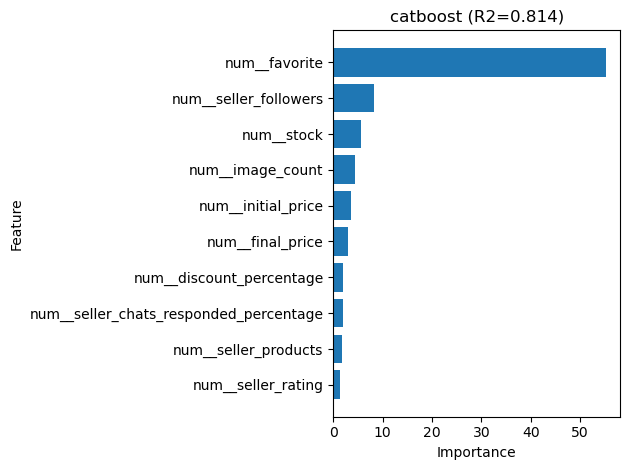

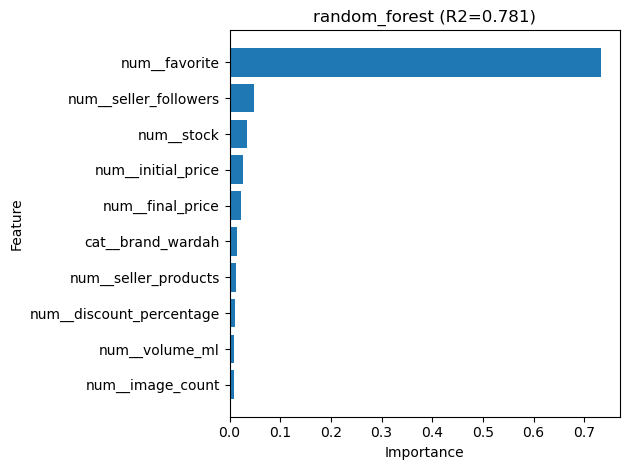

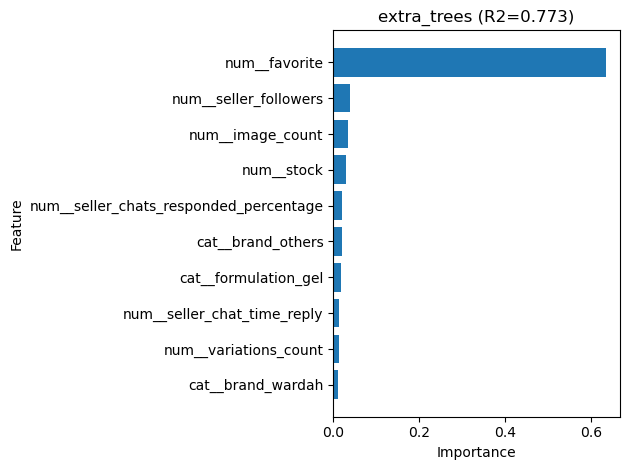


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite   19.973622
                 num__seller_followers    2.919128
                            num__stock    1.975793
                      num__image_count    1.581292
                    num__initial_price    1.275381
                      num__final_price    1.075922
              num__discount_percentage    0.696315
num__seller_chats_responded_percentage    0.671177
                  num__seller_products    0.631426
                    num__seller_rating    0.461071


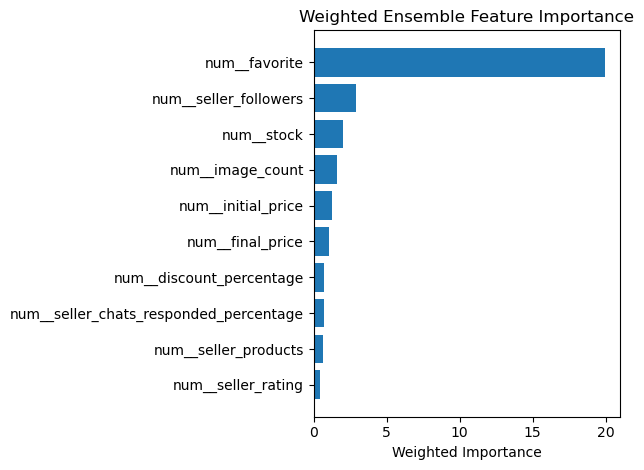


[STAGE] 11. MODEL PERFORMANCE TABLE
        model stage_used     rmse      mae       r2
     catboost      tuned 0.375445 0.244787 0.813549
     ensemble        NaN 0.381006 0.245418 0.807985
random_forest   baseline 0.406778 0.252786 0.781129
  extra_trees      tuned 0.413830 0.270158 0.773475
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 91%|==================  | 492/540 [00:11<00:01]       

[INFO] SHAP summary plot generating...


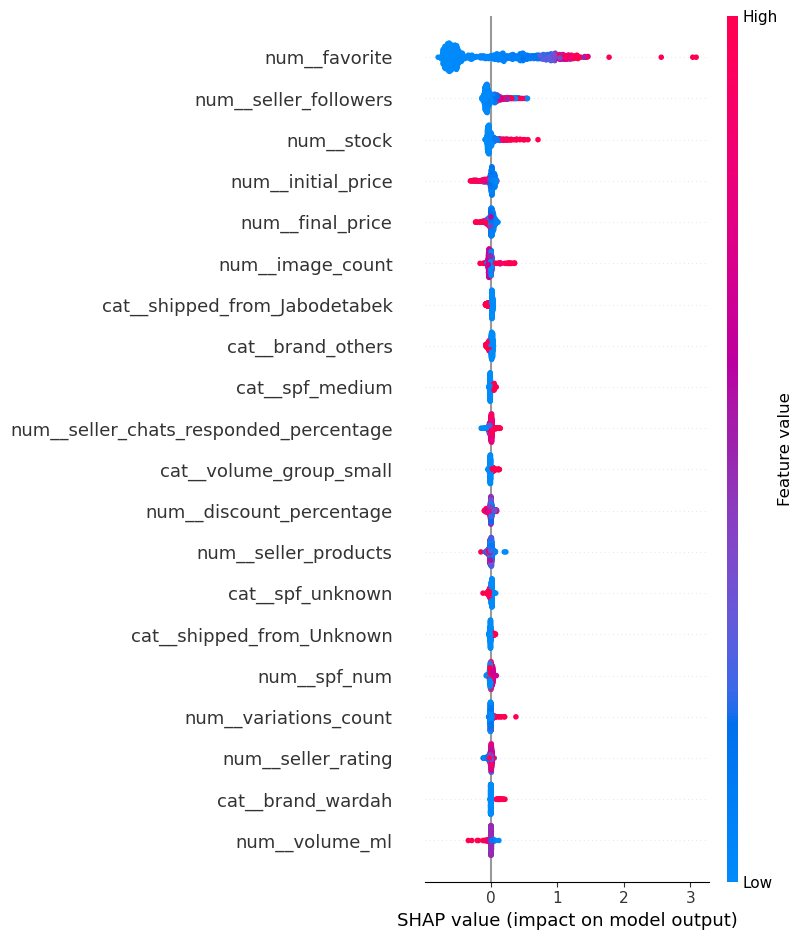


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature       positive_range       negative_range                             recommendation                                     interpretation                                insight
                         num__favorite     61.00 – 27340.00          0.00 – 2.00                          Increase favorite                        favorite ≈ 61.00 – 27340.00 higher values drive better performance
                 num__seller_followers    2.00 – 8156548.00    104.00 – 19400.00                  Increase seller_followers               seller_followers ≈ 2.00 – 8156548.00 higher values drive better performance
                            num__stock 148.00 – 24995859.00        0.00 – 324.00                             Increase stock                       stock ≈ 148.00 – 24995859.00 higher values drive better performance
                    num__initial_price 15000.00 – 299000.00 2900.00 – 1300000.00                       Reduce i

{'results_table':            model stage_used      rmse       mae        r2
 1       catboost      tuned  0.375445  0.244787  0.813549
 3       ensemble        NaN  0.381006  0.245418  0.807985
 2  random_forest   baseline  0.406778  0.252786  0.781129
 0    extra_trees      tuned  0.413830  0.270158  0.773475}

In [54]:
df_sunscreen = df_sunscreen.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_sunscreen)

## SANDAL MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (6400, 44)
[INFO] Validation shape: (1600, 44)
[INFO] Test shape: (2000, 44)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.71906269 0.69426963]
[INFO] Weight STD: [0.02140542 0.02191647]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 50.88% ± 1.51%
[INFO] z_rating_credibility: 49.12% ± 1.55%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.719063    0.021405   50.877113 1.514535
z_rating_credibility    0.694270    0.021916   49.122887 1.550695

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 32

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 20
[INFO] # Categorical: 9
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']

[DE

/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.633635    0.023217     0.443538    0.737822
         lightgbm      0.652737    0.025315     0.455602    0.721482
          xgboost      0.676277    0.032538     0.464719    0.701329
      extra_trees      0.683506    0.024470     0.470858    0.695193
    random_forest      0.686190    0.031294     0.474542    0.692777
            ridge      0.741554    0.023913     0.495312    0.639669
linear_regression      0.743353    0.022958     0.494915    0.637924
      elastic_net      1.137690    0.047688     0.842418    0.156450
            lasso      1.239069    0.046138     0.933294   -0.000888
[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-22 00:00:02,699] Trial 0 finished with value: 0.6435439137870373 and parameters: {'iterations': 699, 'depth': 10, 'learning_rate': 0.05864759857232084, 'l2_leaf_reg': 4.686612600245394, 'border_count': 129}. Best is trial 0 with value: 0.6435439137870373.
[I 2026-04-22 00:00:04,071] Trial 1 finished with value: 0.7986104882572519 and parameters: {'iterations': 367, 'depth': 5, 'learning_rate': 0.010056785540103043, 'l2_leaf_reg': 1.5581275925611, 'border_count': 95}. Best is trial 0 with value: 0.6435439137870373.
[I 2026-04-22 00:00:05,681] Trial 2 finished with value: 0.7306843596053284 and parameters: {'iterations': 401, 'depth': 6, 'learning_rate': 0.023350717137320596, 'l2_leaf_reg': 9.421824353749155, 'border_count': 85}. Best is trial 0 with value: 0.6435439137870373.
[I 2026-04-22 00:00:07,677] Trial 3 finished with value: 0.7044402874069075 and parameters: {'iterations': 376, 'depth': 8, 'learning_rate': 0.029354952609790277, 'l2_leaf_reg': 8.294908312094424, 'borde

[INFO] Best params for catboost: {'iterations': 800, 'depth': 7, 'learning_rate': 0.11611175725259695, 'l2_leaf_reg': 4.753954252386228, 'border_count': 193}


...

[INFO] Tuning model: xgboost


[I 2026-04-22 00:48:16,080] Trial 0 finished with value: 0.6669403478578513 and parameters: {'n_estimators': 632, 'max_depth': 5, 'learning_rate': 0.15488402640116458, 'subsample': 0.7765303898581852, 'colsample_bytree': 0.971854395091829, 'gamma': 0.48284583650760826, 'reg_lambda': 0.001168435435527679}. Best is trial 0 with value: 0.6669403478578513.
[I 2026-04-22 00:48:17,314] Trial 1 finished with value: 0.7990303028311059 and parameters: {'n_estimators': 293, 'max_depth': 3, 'learning_rate': 0.014851811133072516, 'subsample': 0.84769906678334, 'colsample_bytree': 0.6868602594639438, 'gamma': 4.1497350370771535, 'reg_lambda': 5.512095588851275}. Best is trial 0 with value: 0.6669403478578513.
[I 2026-04-22 00:48:19,159] Trial 2 finished with value: 0.7504288150341472 and parameters: {'n_estimators': 359, 'max_depth': 4, 'learning_rate': 0.012162679401264058, 'subsample': 0.9572829587083619, 'colsample_bytree': 0.6846977693956178, 'gamma': 1.4082973515806907, 'reg_lambda': 1.4355432

[INFO] Best params for xgboost: {'n_estimators': 795, 'max_depth': 7, 'learning_rate': 0.04924497027478149, 'subsample': 0.6154924039054037, 'colsample_bytree': 0.9348796410907331, 'gamma': 0.015097864973212916, 'reg_lambda': 0.3256408624010686}

Tuning Summary:
   model                                                                                                                                                                                                           best_params
catboost                                                                                          {'iterations': 800, 'depth': 7, 'learning_rate': 0.11611175725259695, 'l2_leaf_reg': 4.753954252386228, 'border_count': 193}
lightgbm                               {'n_estimators': 595, 'num_leaves': 47, 'learning_rate': 0.052187690621153686, 'feature_fraction': 0.6685751724295715, 'bagging_fraction': 0.9059714289784538, 'min_child_samples': 14}
 xgboost {'n_estimators': 795, 'max_depth': 7, 'learning_rate': 0.04

/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] lightgbm → using tuned model
[INFO] Processing: xgboost
[INFO] xgboost → using tuned model

[STAGE] STAGE 1 vs STAGE 2 COMPARISON
   model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_improvement  r2_improvement
catboost     0.615434    0.437258   0.743744     0.600090    0.422097   0.756363          0.015344         0.015161        0.012618
lightgbm     0.640270    0.449400   0.722644     0.593030    0.411577   0.762062          0.047240         0.037822        0.039417
 xgboost     0.647623    0.453689   0.716237     0.613118    0.425263   0.745669          0.034505         0.028426        0.029432

[STAGE] TOP MODELS FEATURE IMPORTANCE


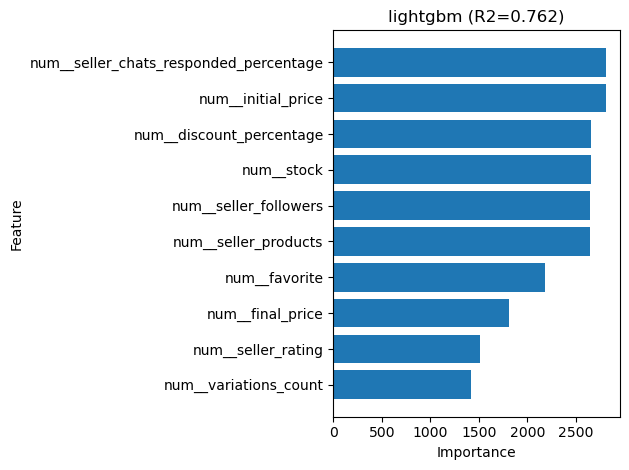

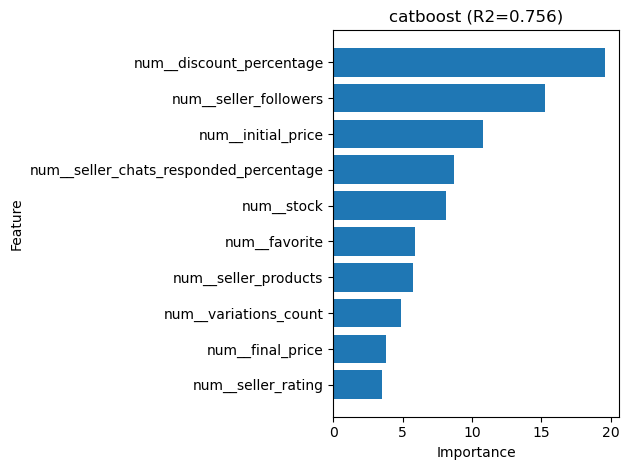

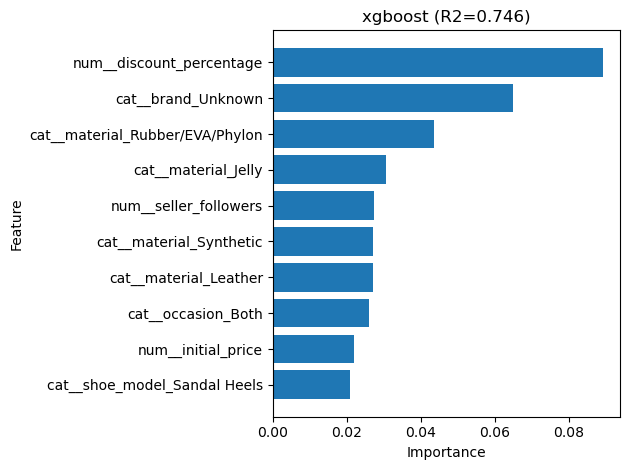


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
num__seller_chats_responded_percentage  954.360936
                    num__initial_price  953.042966
              num__discount_percentage  906.277490
                 num__seller_followers  901.083593
                            num__stock  899.036791
                  num__seller_products  896.534786
                         num__favorite  739.591374
                      num__final_price  613.369534
                    num__seller_rating  510.734353
                 num__variations_count  480.412654


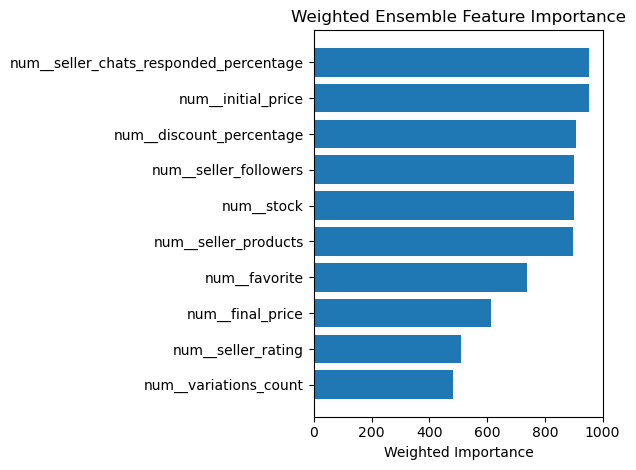


[STAGE] 11. MODEL PERFORMANCE TABLE
   model stage_used     rmse      mae       r2
ensemble        NaN 0.588464 0.408760 0.765712
lightgbm      tuned 0.593030 0.411577 0.762062
catboost      tuned 0.600090 0.422097 0.756363
 xgboost      tuned 0.613118 0.425263 0.745669
[INFO] Best model: lightgbm

[STAGE] 12. SHAP ANALYSIS


 98%|===================| 980/1000 [00:17<00:00]        

[INFO] SHAP summary plot generating...


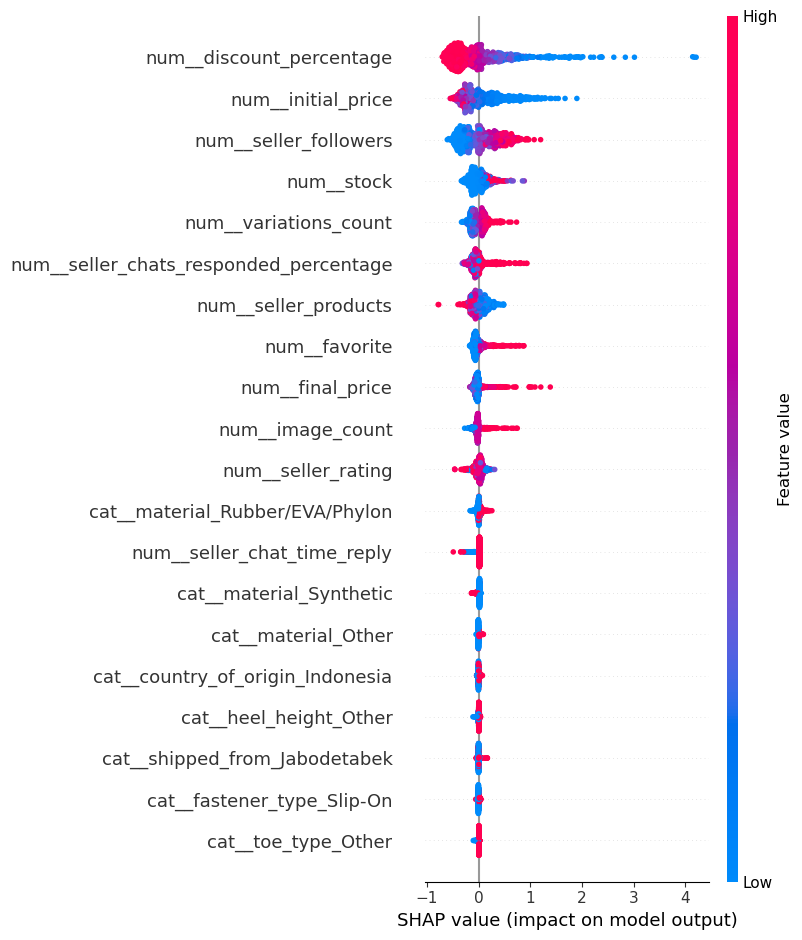


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature        positive_range         negative_range                             recommendation                                     interpretation                                insight
              num__discount_percentage      -590.02 – -17.86          83.33 – 98.68                 Reduce discount_percentage             discount_percentage ≈ -590.02 – -17.86  lower values drive better performance
                    num__initial_price    8000.00 – 53900.00 100000.00 – 1980000.00                       Reduce initial_price                 initial_price ≈ 8000.00 – 53900.00  lower values drive better performance
                 num__seller_followers 166511.17 – 406876.32        0.00 – 54854.08                  Increase seller_followers           seller_followers ≈ 166511.17 – 406876.32 higher values drive better performance
                            num__stock     78.00 – 383833.00           0.00 – 90.00                

/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'results_table':       model stage_used      rmse       mae        r2
 3  ensemble        NaN  0.588464  0.408760  0.765712
 1  lightgbm      tuned  0.593030  0.411577  0.762062
 0  catboost      tuned  0.600090  0.422097  0.756363
 2   xgboost      tuned  0.613118  0.425263  0.745669}

In [60]:
df_sandal = df_sandal.drop(columns=["seller_joined_date", "breadcrumb", "discount"], errors="ignore")
run_pipeline(df_sandal)

## WALLET MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2656, 47)
[INFO] Validation shape: (664, 47)
[INFO] Test shape: (831, 47)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.69984349 0.71355464]
[INFO] Weight STD: [0.02319283 0.02282457]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 49.51% ± 1.64%
[INFO] z_rating_credibility: 50.49% ± 1.61%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct  std_pct
              z_sold    0.699843    0.023193   49.514958 1.640927
z_rating_credibility    0.713555    0.022825   50.485042 1.614872

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 35

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 19
[INFO] # Categorical: 13
[INFO] # Binary: 3

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage', 'seller_chat_tim

/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.755041    0.044918     0.455602    0.618585
         lightgbm      0.757307    0.057294     0.453514    0.615609
          xgboost      0.776435    0.060636     0.456223    0.595520
      extra_trees      0.785698    0.054823     0.456214    0.586863
    random_forest      0.786062    0.036513     0.452442    0.587031
              knn      0.886887    0.057581     0.555310    0.474132
              svr      0.894456    0.053064     0.486734    0.466321
            ridge      0.930657    0.049332     0.647477    0.422005
linear_regression      0.932811    0.049283     0.649177    0.419330
      elastic_net      1.178216    0.049689     0.907365    0.073443
            lasso      1.224523    0.048112     0.961868   -0.001035
[INFO] Top models: ['catboost', 'lightgbm', 'xgboost']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboost


[I 2026-04-21 01:31:25,146] Trial 0 finished with value: 0.7625485427868834 and parameters: {'iterations': 656, 'depth': 8, 'learning_rate': 0.03457443260953431, 'l2_leaf_reg': 9.468836445043344, 'border_count': 47}. Best is trial 0 with value: 0.7625485427868834.
[I 2026-04-21 01:31:28,039] Trial 1 finished with value: 0.7457302935220003 and parameters: {'iterations': 680, 'depth': 7, 'learning_rate': 0.0576798900565162, 'l2_leaf_reg': 2.2248886663091714, 'border_count': 157}. Best is trial 1 with value: 0.7457302935220003.
[I 2026-04-21 01:31:30,696] Trial 2 finished with value: 0.7487970862135345 and parameters: {'iterations': 670, 'depth': 8, 'learning_rate': 0.04386444903424918, 'l2_leaf_reg': 7.076124017410442, 'border_count': 41}. Best is trial 1 with value: 0.7457302935220003.
[I 2026-04-21 01:31:34,143] Trial 3 finished with value: 0.7583566814535289 and parameters: {'iterations': 485, 'depth': 8, 'learning_rate': 0.04617771699915968, 'l2_leaf_reg': 6.064200081387139, 'border_

[INFO] Best params for catboost: {'iterations': 724, 'depth': 8, 'learning_rate': 0.05242498958405567, 'l2_leaf_reg': 3.523649863166827, 'border_count': 183}


...

[INFO] Tuning model: xgboost


[I 2026-04-21 02:04:58,217] Trial 0 finished with value: 0.7552099263551393 and parameters: {'n_estimators': 563, 'max_depth': 7, 'learning_rate': 0.10715813305495078, 'subsample': 0.9834771844762873, 'colsample_bytree': 0.6580432617282711, 'gamma': 0.06977156067442702, 'reg_lambda': 0.0026709866407373497}. Best is trial 0 with value: 0.7552099263551393.
[I 2026-04-21 02:04:59,150] Trial 1 finished with value: 0.8106049224894447 and parameters: {'n_estimators': 505, 'max_depth': 10, 'learning_rate': 0.18112175996195223, 'subsample': 0.8920657111492043, 'colsample_bytree': 0.7697601616254784, 'gamma': 2.0915220099760576, 'reg_lambda': 0.005021442938824623}. Best is trial 0 with value: 0.7552099263551393.
[I 2026-04-21 02:04:59,845] Trial 2 finished with value: 0.8144368685368815 and parameters: {'n_estimators': 228, 'max_depth': 4, 'learning_rate': 0.04535271552074133, 'subsample': 0.855139114585586, 'colsample_bytree': 0.8800695689277636, 'gamma': 4.556798303817527, 'reg_lambda': 0.461

[INFO] Best params for xgboost: {'n_estimators': 756, 'max_depth': 6, 'learning_rate': 0.021501845646819496, 'subsample': 0.8269244476144604, 'colsample_bytree': 0.6662482667711978, 'gamma': 0.11357962065427976, 'reg_lambda': 9.675249119422608}

Tuning Summary:
   model                                                                                                                                                                                                          best_params
catboost                                                                                         {'iterations': 724, 'depth': 8, 'learning_rate': 0.05242498958405567, 'l2_leaf_reg': 3.523649863166827, 'border_count': 183}
lightgbm                              {'n_estimators': 799, 'num_leaves': 40, 'learning_rate': 0.016004969300404046, 'feature_fraction': 0.7170627406813611, 'bagging_fraction': 0.9726480959928147, 'min_child_samples': 11}
 xgboost {'n_estimators': 756, 'max_depth': 6, 'learning_rate': 0.021501

/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[INFO] lightgbm → stage 2 model does not improve performance
[INFO] Processing: xgboost
[INFO] xgboost → using tuned model

[STAGE] STAGE 1 vs STAGE 2 COMPARISON
   model  stage1_rmse  stage1_mae  stage1_r2  stage2_rmse  stage2_mae  stage2_r2  rmse_improvement  mae_improvement  r2_improvement
catboost     0.802563    0.474950   0.580218     0.794494    0.464863   0.588616          0.008069         0.010087        0.008398
lightgbm     0.789985    0.461295   0.593273     0.797437    0.451091   0.585564         -0.007452         0.010204       -0.007709
 xgboost     0.815878    0.481701   0.566174     0.788845    0.457024   0.594446          0.027033         0.024677        0.028272

[STAGE] TOP MODELS FEATURE IMPORTANCE


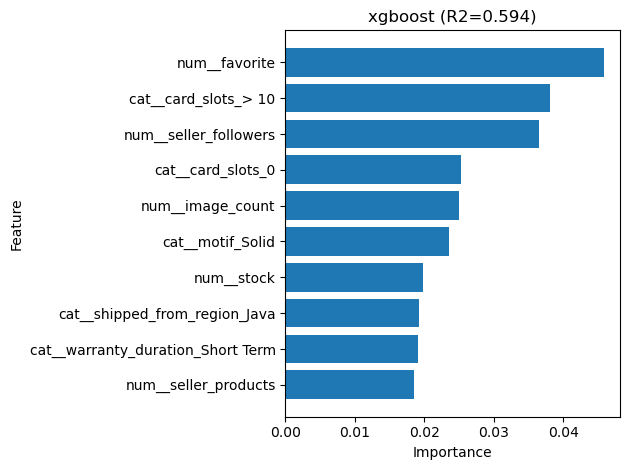

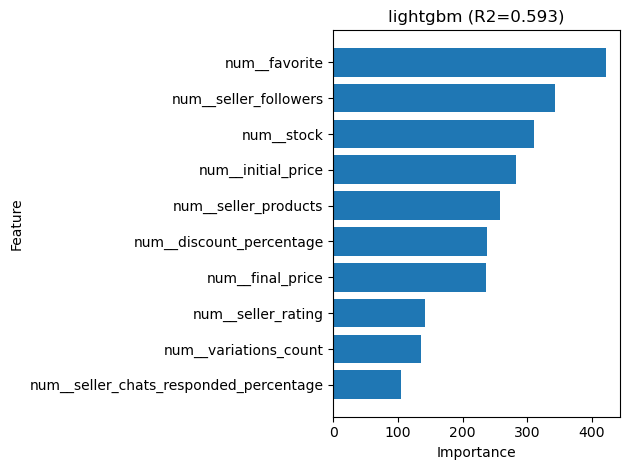

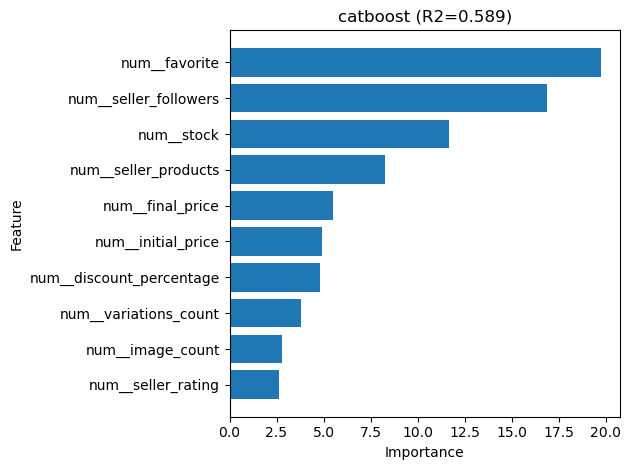


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                               feature  importance
                         num__favorite  147.446118
                 num__seller_followers  119.782024
                            num__stock  107.352513
                    num__initial_price   96.104899
                  num__seller_products   88.881229
              num__discount_percentage   80.705342
                      num__final_price   80.615169
                    num__seller_rating   47.950784
                 num__variations_count   46.326618
num__seller_chats_responded_percentage   35.685298


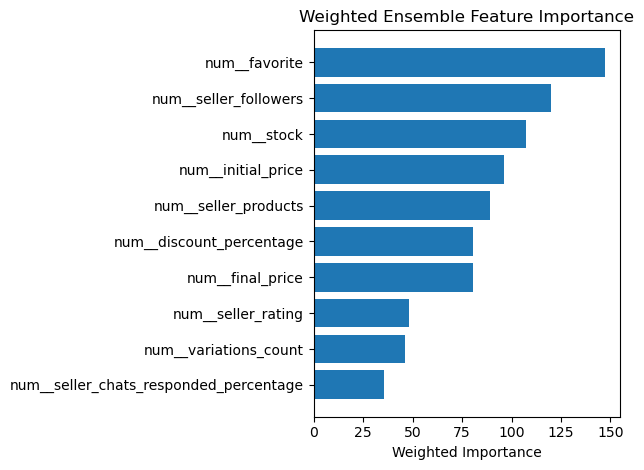


[STAGE] 11. MODEL PERFORMANCE TABLE
   model stage_used     rmse      mae       r2
ensemble        NaN 0.780583 0.448499 0.602896
 xgboost      tuned 0.788845 0.457024 0.594446
lightgbm   baseline 0.789985 0.461295 0.593273
catboost      tuned 0.794494 0.464863 0.588616
[INFO] Best model: xgboost

[STAGE] 12. SHAP ANALYSIS


 92%|==================  | 611/664 [00:11<00:00]       

[INFO] SHAP summary plot generating...


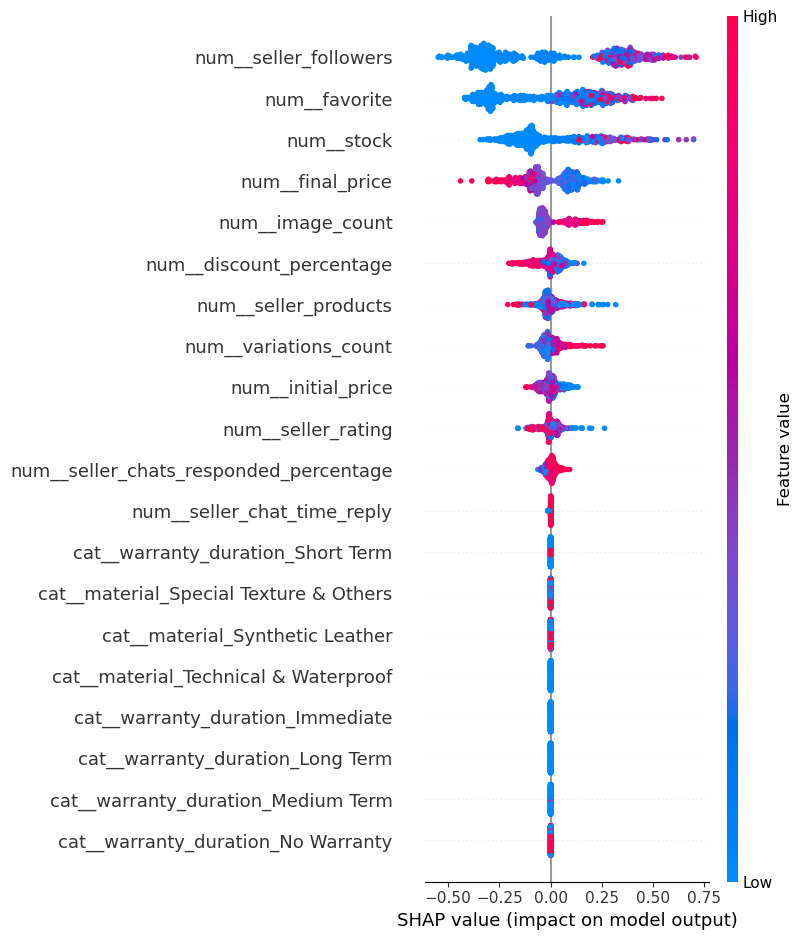


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature       positive_range       negative_range                             recommendation                                     interpretation                                insight
                 num__seller_followers 50200.00 – 695400.00     20.00 – 26700.00                  Increase seller_followers            seller_followers ≈ 50200.00 – 695400.00 higher values drive better performance
                         num__favorite       24.00 – 997.00         0.00 – 10.00                          Increase favorite                          favorite ≈ 24.00 – 997.00 higher values drive better performance
                            num__stock    218.00 – 24899.00         0.00 – 89.00                             Increase stock                          stock ≈ 218.00 – 24899.00 higher values drive better performance
                      num__final_price   3999.00 – 66650.00 70000.00 – 439000.00                         Reduce

{'results_table':       model stage_used      rmse       mae        r2
 3  ensemble        NaN  0.780583  0.448499  0.602896
 2   xgboost      tuned  0.788845  0.457024  0.594446
 1  lightgbm   baseline  0.789985  0.461295  0.593273
 0  catboost      tuned  0.794494  0.464863  0.588616}

In [56]:
df_wallet = df_wallet.drop(columns=["seller_joined_date", "breadcrumb", "discount", "log_gmv"], errors="ignore")
run_pipeline(df_wallet)

## PAN MAIN PIPELINE


[STAGE] 1. DATA SPLIT
[INFO] Train shape: (2912, 42)
[INFO] Validation shape: (728, 42)
[INFO] Test shape: (911, 42)

[STAGE] 2. TARGET ENGINE (PCA + BOOTSTRAP)
[INFO] PCA Weights: [0.76793992 0.55304514]
[INFO] Weight STD: [0.20679999 0.24828033]

[STAGE] PCA NORMALIZED WEIGHTS (%)
[INFO] z_sold: 58.13% ± 15.65%
[INFO] z_rating_credibility: 41.87% ± 18.80%

PCA Weight Summary Table:
           component  weight_raw  weight_std  weight_pct   std_pct
              z_sold    0.767940     0.20680   58.133884 15.654983
z_rating_credibility    0.553045     0.24828   41.866116 18.795090

[STAGE] 3. FEATURE SELECTION
[INFO] Selected features: 30

[STAGE] 4. FEATURE TYPE DETECTION
[INFO] # Numeric: 20
[INFO] # Categorical: 8
[INFO] # Binary: 2

[STAGE] 5. BUILD PIPELINES

[DEBUG] Linear features:
['log_final_price', 'log_initial_price', 'log_stock', 'log_favorite', 'log_gmv', 'log_seller_followers', 'log_seller_products', 'log_discount', 'seller_rating', 'seller_chats_responded_percentage']



/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/dataanalysis/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe


[STAGE] STAGE 1 MODEL PERFORMANCE TABLE
            model  cv_rmse_mean  cv_rmse_sd  cv_mae_mean  cv_r2_mean
         catboost      0.808997    0.213499     0.480007    0.468938
          xgboost      0.835942    0.134469     0.492455    0.413723
    random_forest      0.857744    0.174079     0.488553    0.383965
         lightgbm      0.900717    0.230491     0.502601    0.357847
      extra_trees      0.956330    0.249308     0.524072    0.253506
              svr      0.973464    0.269810     0.466001    0.259422
              knn      0.975959    0.250767     0.535911    0.242937
            ridge      1.064763    0.254356     0.622255    0.099720
linear_regression      1.071945    0.253381     0.628167    0.086619
            lasso      1.121098    0.259817     0.704318   -0.000991
      elastic_net      1.121098    0.259817     0.704318   -0.000991
[INFO] Top models: ['catboost', 'xgboost', 'random_forest']

[STAGE] 8. STAGE 2: HYPERPARAMETER TUNING
[INFO] Tuning model: catboos

[I 2026-04-21 02:10:32,059] Trial 0 finished with value: 0.8400219840094121 and parameters: {'iterations': 403, 'depth': 6, 'learning_rate': 0.033391111670259106, 'l2_leaf_reg': 5.564034262591021, 'border_count': 173}. Best is trial 0 with value: 0.8400219840094121.
[I 2026-04-21 02:10:40,200] Trial 1 finished with value: 0.866365339342958 and parameters: {'iterations': 622, 'depth': 10, 'learning_rate': 0.08297921660039388, 'l2_leaf_reg': 3.3432522624741923, 'border_count': 59}. Best is trial 0 with value: 0.8400219840094121.
[I 2026-04-21 02:10:41,214] Trial 2 finished with value: 0.8284910084387169 and parameters: {'iterations': 372, 'depth': 5, 'learning_rate': 0.04970814537785576, 'l2_leaf_reg': 4.182134101972849, 'border_count': 76}. Best is trial 2 with value: 0.8284910084387169.
[I 2026-04-21 02:10:53,804] Trial 3 finished with value: 0.8515839634861326 and parameters: {'iterations': 495, 'depth': 10, 'learning_rate': 0.06889619256285254, 'l2_leaf_reg': 7.309969972563393, 'bord

[INFO] Best params for catboost: {'iterations': 752, 'depth': 5, 'learning_rate': 0.05752106632368512, 'l2_leaf_reg': 1.234361521138296, 'border_count': 202}


...

[INFO] Best params for xgboost: {'n_estimators': 242, 'max_depth': 4, 'learning_rate': 0.09605158173865629, 'subsample': 0.8290761056946285, 'colsample_bytree': 0.9713330288632794, 'gamma': 0.4539576305259826, 'reg_lambda': 0.9929892619837665}


[I 2026-04-21 02:17:00,777] A new study created in memory with name: no-name-bf3c5677-d4e3-4ae4-b91f-4dbe67656483


[INFO] Tuning model: random_forest


[I 2026-04-21 02:17:02,662] Trial 0 finished with value: 1.0088299652990744 and parameters: {'n_estimators': 250, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 1.0088299652990744.
[I 2026-04-21 02:17:04,933] Trial 1 finished with value: 0.9801534388918952 and parameters: {'n_estimators': 260, 'max_depth': 26, 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9801534388918952.
[I 2026-04-21 02:17:06,443] Trial 2 finished with value: 0.9894688063531589 and parameters: {'n_estimators': 238, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9801534388918952.
[I 2026-04-21 02:17:07,163] Trial 3 finished with value: 1.0314965496636872 and parameters: {'n_estimators': 145, 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 1 with value: 0.98015343889189

[INFO] Best params for random_forest: {'n_estimators': 159, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

Tuning Summary:
        model                                                                                                                                                                                                         best_params
     catboost                                                                                        {'iterations': 752, 'depth': 5, 'learning_rate': 0.05752106632368512, 'l2_leaf_reg': 1.234361521138296, 'border_count': 202}
      xgboost {'n_estimators': 242, 'max_depth': 4, 'learning_rate': 0.09605158173865629, 'subsample': 0.8290761056946285, 'colsample_bytree': 0.9713330288632794, 'gamma': 0.4539576305259826, 'reg_lambda': 0.9929892619837665}
random_forest                                                                                                       {'n_estimators': 159, 'max_depth': 25, 'm

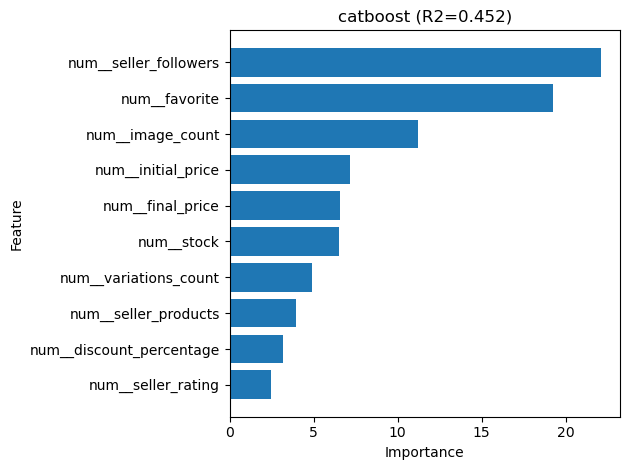

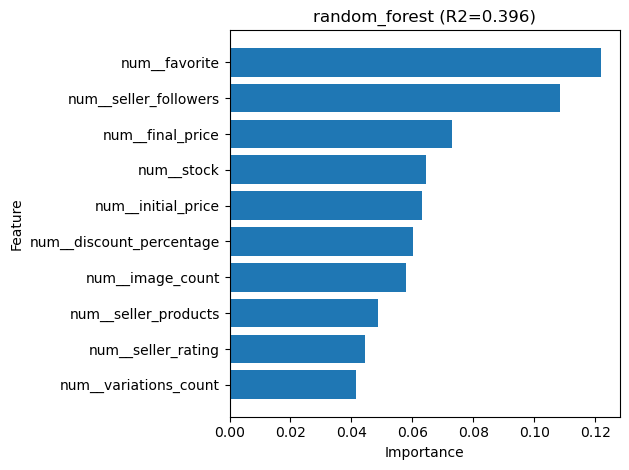

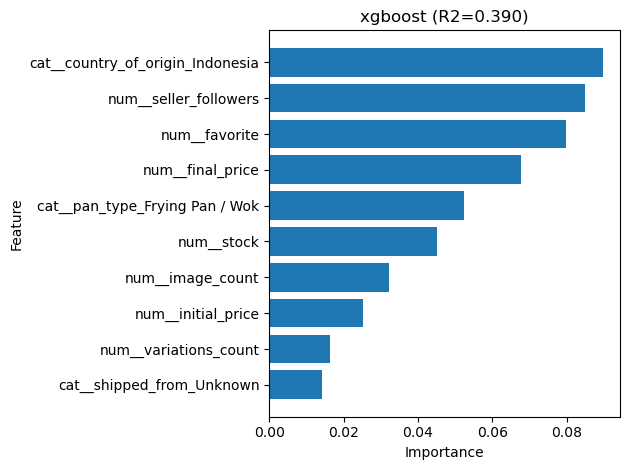


[STAGE] 10. ENSEMBLE

[STAGE] ENSEMBLE FEATURE IMPORTANCE
                 feature  importance
   num__seller_followers    7.690646
           num__favorite    6.700913
        num__image_count    3.886964
      num__initial_price    2.499223
        num__final_price    2.317096
              num__stock    2.286687
   num__variations_count    1.711406
    num__seller_products    1.377570
num__discount_percentage    1.129626
      num__seller_rating    0.862566


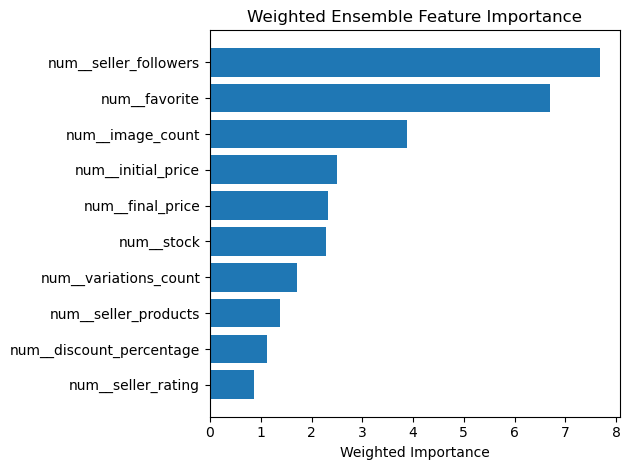


[STAGE] 11. MODEL PERFORMANCE TABLE
        model stage_used     rmse      mae       r2
     ensemble        NaN 0.555532 0.454077 0.452513
     catboost   baseline 0.555855 0.444465 0.451875
random_forest      tuned 0.583328 0.489899 0.396355
      xgboost      tuned 0.586433 0.458225 0.389912
[INFO] Best model: catboost

[STAGE] 12. SHAP ANALYSIS


 98%|===================| 712/728 [00:15<00:00]        

[INFO] SHAP summary plot generating...


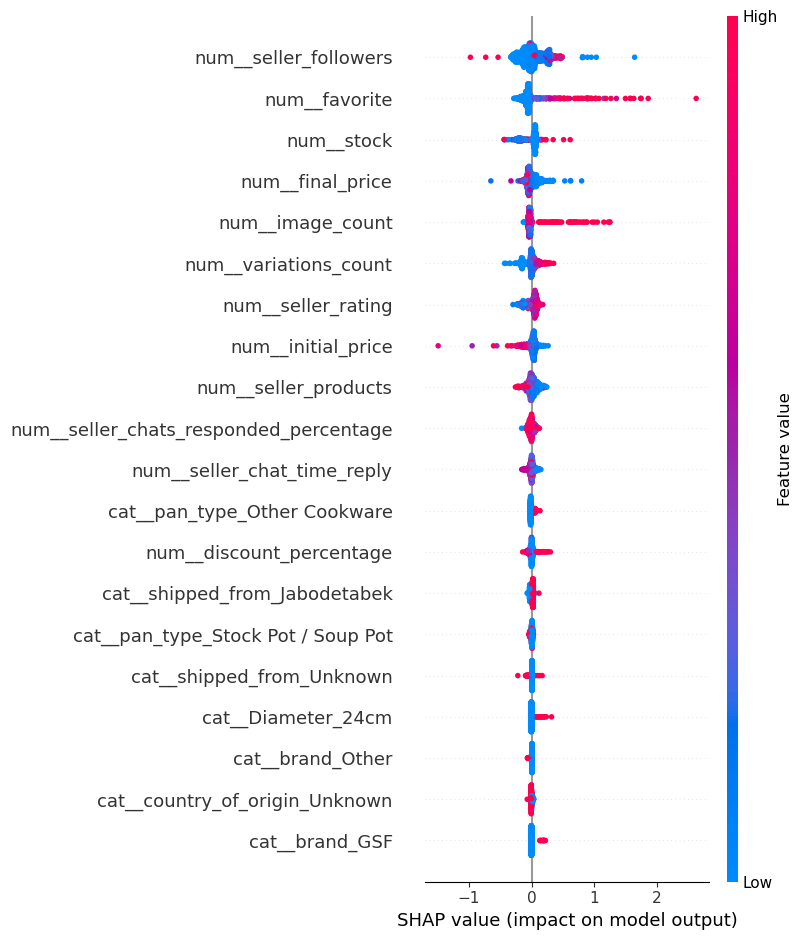


[STAGE] SHAP THRESHOLD ANALYSIS
                               feature      positive_range        negative_range                           recommendation                                    interpretation                                insight
                 num__seller_followers   2.00 – 2413664.00      0.00 – 970000.00                Increase seller_followers              seller_followers ≈ 2.00 – 2413664.00 higher values drive better performance
                         num__favorite      0.00 – 4938.00          0.00 – 41.00                        Increase favorite                         favorite ≈ 0.00 – 4938.00 higher values drive better performance
                            num__stock    0.00 – 119911.00     3.00 – 1777657.00                             Reduce stock                          stock ≈ 0.00 – 119911.00  lower values drive better performance
                      num__final_price 8888.00 – 109900.00 93100.00 – 2580000.00                       Reduce final_price  

{'results_table':            model stage_used      rmse       mae        r2
 3       ensemble        NaN  0.555532  0.454077  0.452513
 0       catboost   baseline  0.555855  0.444465  0.451875
 2  random_forest      tuned  0.583328  0.489899  0.396355
 1        xgboost      tuned  0.586433  0.458225  0.389912}

In [57]:
df_pan = df_pan.drop(columns=["seller_joined_date", "discount"], errors="ignore")
run_pipeline(df_pan)